In [150]:
import os
import json
import datasets

nnet_live_dir = '/home/jadeleiyu/projects/mbrl_agent/world_model/sft_data/Nnetnav/live/'

# nnetnav-live dataset
with open(os.path.join(nnet_live_dir, "train_wm.jsonl"), 'r') as f:
    nnet_live_wm_ds = json.load(f)
nnet_live_wm_ds = list(nnet_live_wm_ds.items())

# webarena data from WMA paper
ds_wm_wa = datasets.load_dataset('LangAGI-Lab/world_model_for_wa_desc_with_tao_dataset', split='train')

In [161]:
from tqdm import tqdm

input_data = []

for task_id, example in tqdm(nnet_live_wm_ds):
    for step in example['steps']:
        input_data_i = {
            "objective": example['objective'],
            "current_observation": step['current_observation'],
            "current_url": "",
            "previous_action": step['previous_actions'].split('\n')[-1],
            "current_action": step['current_action'],
            "next_observation": step['next_observation'],
            "source_dataset": 'stanfordnlp/nnetnav-live'
        }
        input_data.append(input_data_i)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5017/5017 [00:00<00:00, 92820.70it/s]


In [162]:
for example in tqdm(ds_wm_wa):
    input_data_i = {
        "objective": example['objective'],
        "current_observation": example['observation'],
        "current_url": example['url'],
        "previous_action": example['previous_actions'][-1],
        "current_action": example['current_action'],
        "next_observation": example['next_state_acctree'],
        "source_dataset": 'LangAGI-Lab/world_model_for_wa_desc_with_tao_dataset'
    }
    input_data.append(input_data_i)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14744/14744 [00:01<00:00, 12710.61it/s]


In [170]:
with open("/home/jadeleiyu/projects/mbrl_agent/world_model/sft_data/wm_cot_gen_inputs.json", 'w') as f:
     json.dump(input_data, f)

In [ ]:
with open(os.path.join(f"/home/jadeleiyu/projects/mbrl_agent/world_model/sft_data/wm_cot_gen_outputs_0.jsonl"), 'r') as f:
    wm_cot_data_i = json.load(f)

{'objective': 'Find detailed information about the chemistry of water, including its structure and properties.',
 'current_observation': 'RootWebArea \'Wolfram|Alpha: Computational Intelligence\', focused, url=\'https://www.wolframalpha.com/\'\n\t[51] banner \'\', visible\n\t\t[52] navigation \'\', visible\n\t\t\t[53] list \'\', visible\n\t\t\t\t[54] listitem \'\', visible\n\t\t\t\t\t[55] button \'UPGRADE TO PRO\', clickable, visible, hasPopup=\'menu\', expanded=False\n\t\t\t\t\t\tStaticText \'UPGRADE TO PRO\'\n\t\t\t\t\t\t[57] image \'\', visible\n\t\t\t\t[58] listitem \'\', visible\n\t\t\t\t\t[59] button \'APPS\', clickable, visible, hasPopup=\'menu\', expanded=False\n\t\t\t\t\t\tStaticText \'APPS\'\n\t\t\t\t\t\t[61] image \'\', visible\n\t\t\t\t[62] listitem \'\', visible\n\t\t\t\t\t[63] link \'TOUR\', clickable, visible, url=\'https://www.wolframalpha.com/tour\'\n\t\t\t\t\t\tStaticText \'TOUR\'\n\t\t\t\t[65] listitem \'\', visible\n\t\t\t\t\t[66] button \'Sign in\', clickable, visi
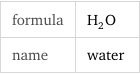
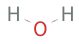
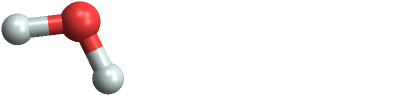

In [178]:
wm_cot_data_i[0]

In [174]:
len(wm_cot_data_i[0])

7257

In [176]:
print(wm_cot_data_i[0][0]['wm_cot'])

[Rationale]
The action performed was to type “water chemistry” into the input textbox (id 89) on the Wolfram|Alpha homepage and then press Enter. The resulting request sent the query to the Wolfram|Alpha engine, which returned a new page that contains the computed answer and associated interpretive elements. Therefore the changes to the page state are: the textbox now contains the query string, the page URL updates to reflect the query, and a large set of new content nodes are injected into the main area to display the answer. No existing elements were removed; only the value of the textbox was altered and new child nodes were added under the main content area.

[Web state changes]
1. **URL change** – The browser’s current URL updates from `https://www.wolframalpha.com/` to `https://www.wolframalpha.com/input?i=water+chemistry`.

2. **Textbox value update** – The node `[89] textbox 'WolframAlpha input field'` now has `value='water chemistry'` (previously empty).

3. **New main content*